# 10 Sense chain, board against board

Notebook 00 section 10 put board D on a resistor grid with a multimeter next to it, and that
session is where most of board D's measured chain figures in `oscnb/boards.py` come from. The
rev-2A board is meant to fix what that session found, so the obvious next step is to run the
same session on 2A and put the two boards side by side.

This notebook is that side by side. It reruns the section 10 measurements for any grid
dataset, picks the board from each recording's own `sense` block, and prints one table at the
end with a column per dataset. Nothing in here names a board. A rev-2A dataset that lands
under `telemetry/` as `grid-3r7__dev-v006-2A__2s` gets its own column the next time the
notebook runs.

If you only want the short version:

- Board D reproduces here. VDD 3.28 V, the terminal chain within 0.44% of the meter's band,
  the current chain about 1% high with a 3% bracket, an honest crest current from 15% duty
  on 2S, and a shunt edge that settles 4.3 us after the ON edge.
- The rev-2A column is empty until its grid session is captured.
- Board #1 of rev 2A has an open Rv3, so its tap B reads the bias node instead of terminal
  B. Section 2 says how the notebook copes with that, and what it costs.

## 1. The datasets

Each grid dataset is one board on one supply with the 3.7 ohm grid on the motor terminals.
The board is not declared anywhere. It comes from the first recording's `sense` block, and
reading any other recording checks its block against the same entry, so a dataset that mixes
two boards fails at load.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import oscnb

Q15 = 32767

# Every grid session this notebook knows how to grade. A dataset that has not been captured
# yet is reported and skipped, so the rev-2A column appears the day its folder lands.
GRIDS = [
    "grid-3r7__dev-v006-D__2s",
    "grid-3r7__dev-v006-D__usb",
    "grid-3r7__dev-v006-2A__2s",
]
FOUND = oscnb.datasets.find()
GDS = {k: FOUND[k] for k in GRIDS if k in FOUND}
for k in GRIDS:
    if k not in FOUND:
        print(f"{k}: not captured yet, skipped")

# Short column labels: the board key the sense block picked, plus the supply.
LABEL = {k: f"{d.board.key} {d.supply}" for k, d in GDS.items()}

# What each board's parts make of one count, straight off the registry entry.
pd.DataFrame({
    LABEL[k]: {
        "drive rule": d.rule,
        "shunt [mOhm]": d.board.shunt_mohm,
        "amplifier gain": d.board.amp_gain,
        "current [counts per A]": round(d.board.counts_per_a, 1),
        "terminal divider ratio r": round(d.board.div_ratio, 4),
        "terminal [mV per count]": round(d.board.v_term_per_count * 1e3, 3),
        "VB nominal [counts]": round(d.board.vb_nom_counts, 1),
        "rail tap ratio": d.board.vbus_ratio,
        "load [ohm]": d.servo.measured["r_load"].value,
    } for k, d in GDS.items()})

grid-3r7__dev-v006-2A__2s: not captured yet, skipped


,dev-v006-D 2s,dev-v006-D usb
drive rule,free,free
shunt [mOhm],60,60
amplifier gain,15.0,15.0
current [counts per A],1117.1,1117.1
terminal divider ratio r,3.0606,3.0606
terminal [mV per count],2.466,2.466
VB nominal [counts],779.4,779.4
rail tap ratio,2.5,2.5
load [ohm],3.7,3.7


## 2. Reading a recording

Three rules apply to every recording below, and they are the only places where the two boards
could need different handling.

**When a rung counts as settled.** Board D was captured before the servo limited open-loop
current, so every rung stepped straight to its duty. A rev-2A capture runs under the current
limit, which raises the duty from the window floor at about 0.4% per tick, so a rung from rest
to 100% takes about 11 ms to arrive. A rung counts from the first sample where the applied
duty reaches its held value, and never earlier than 40 samples (2 ms) after it opens, which is
the settle notebook 00 used for the rail and the taps. On board D the applied duty arrives in
one or two samples, so the 2 ms rule is the one that binds and nothing changes.

**Which terminal is high.** A rung drives terminal A high when tap A reads above tap B. On
board D that is the same as positive duty. It does not depend on the drive polarity setting.

**Whether tap B is a terminal.** A working tap B swings by hundreds of counts when its
terminal drives. Board #1 of rev 2A has Rv3 open, so nothing connects tap B to terminal B and
the 1k6 bottom leg ties it to the bias node. That tap reads $V_B$ itself, live, including the
rise the bias node takes under drive. So on a board like that the notebook uses tap A alone,
on rungs where A is the high side, and converts it with tap B as the bias:

$$V_A = r\,\text{tap}_A - (r - 1)\,\text{tap}_B .$$

What tap A alone cannot see is the low side. The load sees $V_A - V_B$, and $V_B$ on the
driven-low terminal is the current times the low-side switch, the shunt and the copper, about
0.45 V at 1.7 A on board D. So on the tap-A route an apparent resistance carries that path
too, and a terminal reading graded against the meter has to be graded against the meter on
MOT_A to ground, not across the grid. A ratio of two rungs still cancels it, because the low
side is ohmic and scales with the same current. The reverse laps, where A is the low side,
measure that path on the A side directly.

In [2]:
SKIP_SAMPLES = 40    # 2 ms after a rung opens, for the rail and the taps to settle
FRAMES = {}


def frame(rec):
    # rec.frame() checks the recording's sense block and drive rule against its dataset.
    # Cached, because several sections read the same ladders.
    if str(rec) not in FRAMES:
        FRAMES[str(rec)] = rec.frame()
    return FRAMES[str(rec)]


def settled(g):
    # The applied duty this rung held, from its second half, then the first sample that
    # reached it. Under the limit rule that is the end of the climb from the window floor.
    held = g["duty_q15"].iloc[len(g) // 2:].median()
    at = np.flatnonzero(g["duty_q15"].to_numpy() == held)
    return g.iloc[max(SKIP_SAMPLES, at[0] if len(at) else len(g)):]


def tap_b_is_terminal(d):
    # Largest rise of tap B over its own rest reading, across the first ladder capture.
    swing = 0.0
    cap = d.captures("ladder")[0]
    for rec in d.recordings("ladder", cap):
        df = frame(rec)
        rest = df[df["seg"] == 0]["vmotor_b"].median()
        swing = max(swing, (df[df["seg"] > 0].groupby("seg")["vmotor_b"].median() - rest).max())
    return swing > 200


ROUTE = {k: ("ab" if tap_b_is_terminal(d) else "a") for k, d in GDS.items()}

# The meter log of each session, and VDD from it. VDD is the ADC reference, so every absolute
# volt and amp scales with it. K_VDD is applied wherever an absolute number is quoted and
# nowhere a ratio of two readings off the same chain is.
def meter(d):
    p = d.path / "dclap" / "dmm.csv"
    return pd.read_csv(p, dtype={"lap": str}) if p.exists() else None


K_VDD, VDD = {}, {}
for k, d in GDS.items():
    m = meter(d)
    row = m[(m["lap"] == "setup") & m["where"].str.startswith("VDD")] if m is not None else []
    VDD[k] = float(row["v_lo"].iloc[0]) if len(row) else np.nan
    K_VDD[k] = VDD[k] / (d.board.vdd_mv / 1e3) if len(row) else 1.0

CARD = {k: {} for k in GDS}
for k, d in GDS.items():
    CARD[k]["terminal route"] = "taps A and B" if ROUTE[k] == "ab" else "tap A, tap B reads VB"
    CARD[k]["VDD by meter [V]"] = VDD[k]
    print(f"{LABEL[k]:<20} {CARD[k]['terminal route']:<24} VDD {VDD[k]:.3f} V, "
          f"absolute numbers scaled by {K_VDD[k]:.5f}")

dev-v006-D 2s        taps A and B             VDD 3.280 V, absolute numbers scaled by 0.99394
dev-v006-D usb       taps A and B             VDD 3.280 V, absolute numbers scaled by 0.99394


Every number below is a mean over samples, so a missing sample only matters if there are many
of them. The tick counter rides along with every sample, which makes a gap provable from the
data. This counts the gaps inside each drive or rest segment, next to the rows the servo itself
reported dropping when it wrote the recording.

In [3]:
rows = []
for k, d in GDS.items():
    for exp in [e for e in ("ladder", "dclap") if e in d.experiments]:
        for cap in d.captures(exp):
            for rec in d.recordings(exp, cap):
                df = frame(rec)
                gaps = (df.groupby("seg")["tick"].diff().dropna() != 1).sum()
                rows.append({"dataset": LABEL[k], "experiment": exp, "samples": len(df),
                             "tick gaps": gaps, "rows dropped (servo)": rec.meta.get("rows_dropped", 0)})
pd.DataFrame(rows).groupby(["dataset", "experiment"]).agg(
    recordings=("samples", "size"), samples=("samples", "sum"),
    tick_gaps=("tick gaps", "sum"), rows_dropped=("rows dropped (servo)", "sum"))

,,recordings,samples,tick_gaps,rows_dropped
dataset,experiment,,,,
dev-v006-D 2s,ladder,10,266000,0,0
dev-v006-D usb,ladder,3,86000,0,0


## 3. At rest

The torque-off baseline that opens every ladder capture. A static load has no shaft ringing
down, so the whole second counts. The bias node reads directly on both taps here, because with
the bridge off no current flows through either divider.

The current channel's standard deviation here is the noise a single crest sample carries. It
is not the 2.2 counts the registry quotes as board D's amplifier floor, which came from a
bringup bench run with the amplifier on its own, so the two sit in separate rows below.

In [4]:
REST = {}
for k, d in GDS.items():
    b, kv = d.board, K_VDD[k]
    caps = d.captures("ladder")
    base = [frame(r)[lambda x: x["seg"] == 0] for c in caps
            for r in d.recordings("ladder", c) if r.name == "ladder"]
    sd = pd.DataFrame([g[["current_raw", "vmotor_a", "vmotor_b", "vbus_raw"]].std() for g in base]).mean()
    mean = pd.DataFrame([g[["current_raw", "vmotor_a", "vmotor_b", "vbus_raw"]].mean() for g in base]).mean()
    # Bus-coupling check: rest current binned by position in the 16-sample telemetry frame.
    by = base[0].groupby(base[0]["tick"] % 16)["current_raw"].mean()
    c = CARD[k]
    c["VB rest, tap A [counts]"] = mean["vmotor_a"]
    c["VB rest, tap B [counts]"] = mean["vmotor_b"]
    c["VB nominal [counts]"] = b.vb_nom_counts
    c["VB rest, tap A [mV]"] = mean["vmotor_a"] * b.v_adc_per_count * kv * 1e3
    m = meter(d)
    vb = m[(m["lap"] == "setup") & m["where"].str.startswith("VB")] if m is not None else []
    c["VB by meter [mV]"] = float(vb["v_lo"].iloc[0]) * 1e3 if len(vb) else np.nan
    c["rest current sd [counts]"] = sd["current_raw"]
    c["rest current sd [mA]"] = sd["current_raw"] * b.a_per_count * kv * 1e3
    c["rest tap A sd [mV at the terminal]"] = sd["vmotor_a"] * b.v_term_per_count * kv * 1e3
    c["rest rail sd [mV]"] = sd["vbus_raw"] * b.v_adc_per_count * b.vbus_ratio * kv * 1e3
    c["frame-position spread [counts]"] = by.max() - by.min()
    REST[k] = len(base)

pd.DataFrame({LABEL[k]: {q: v for q, v in CARD[k].items() if q.startswith(("VB", "rest", "frame"))}
              for k in GDS}).round(3)

,dev-v006-D 2s,dev-v006-D usb
"VB rest, tap A [counts]",779.168,779.059
"VB rest, tap B [counts]",783.146,783.023
VB nominal [counts],779.401,779.401
"VB rest, tap A [mV]",623.943,623.856
VB by meter [mV],NaN,NaN
rest current sd [counts],1.697,1.902
rest current sd [mA],1.510,1.692
rest tap A sd [mV at the terminal],2.009,1.802
rest rail sd [mV],4.336,3.403
frame-position spread [counts],0.586,0.636


## 4. DC laps against the meter

A DC lap holds 100% duty for a few seconds while the meter sits on one node, and at 100% the
bridge does not switch at all, so the meter and the chip read the same DC quantity. Board D's
laps were polled once a second and typed into `dclap/chip.csv` by hand. The rev-2A laps are
`osc sweep` recordings under `dclap/capture-N`, one lap each, so the lap number is the capture
number and the chip side is the full-rate stream. Both end up in the same per-lap table.

A lap is left out when no current flowed (the meter's dead 10 A jack on board D opened the
loop) or when the applied duty fell to zero during the hold (a brown-out reboot).

The meter log names where the probes were. Each name maps to the quantity it grades:

| meter row | graded against |
|---|---|
| `OUTA-OUTB pads [V]`, `MOT_A-MOT_B at J4 [V]` | the terminal difference, both taps |
| `grid header pins [V]` | the terminal difference, and the current as volts over the grid |
| `MOT_A to GND [V]` | tap A alone, absolute |
| `VSYS to GND [V]` | the rail tap under load |
| `10 A jack in series at the grid header [A]` | the current, directly |
| `Rs1 pads [mV]` | the amplifier gain alone, current times nominal shunt cancels |
| `VB at Cb1 to GND [V]` | in setup, the rest taps; during a lap, a tap B that reads the bias node |

In [5]:
KIND = {"OUTA-OUTB pads [V]": "pads", "MOT_A-MOT_B at J4 [V]": "pads",
        "grid header pins [V]": "grid", "MOT_A to GND [V]": "tap_a", "VSYS to GND [V]": "rail",
        "10 A jack in series at the grid header [A]": "ammeter", "Rs1 pads [mV]": "shunt_mv", "VB at Cb1 to GND [V]": "vb"}
COLS = ["vmotor_a", "vmotor_b", "current", "vbus_raw"]


def laps_polled(d):
    # Board D: one printed row per second, t_s 0 is the rest line before the drive.
    chip = pd.read_csv(d.path / "dclap" / "chip.csv", dtype={"lap": str})
    chip = chip[chip["supply"] == d.supply]
    out = []
    for (lap, duty), g in chip.groupby(["lap", "duty_pct"], sort=False):
        rest = g[g["t_s"] == 0].iloc[0]
        hold = g[(g["t_s"] > 0) & (g["duty_applied_q15"].abs() > 0)].dropna(subset=COLS)
        if not len(hold):
            continue
        out.append({"lap": lap, "duty_pct": duty, "seconds": len(hold),
                    "cut": bool((g[g["t_s"] > 0]["duty_applied_q15"] == 0).any()),
                    **{f"rest_{c}": rest[c] for c in COLS}, **hold[COLS].mean().to_dict()})
    return out


def laps_streamed(d):
    # Rev 2A: one sweep recording per lap, seg 0 the torque-off rest, the rest the hold.
    out = []
    for cap in d.captures("dclap"):
        df = frame(d.recordings("dclap", cap)[0]).rename(columns={"current_raw": "current"})
        rest = df[df["seg"] == 0]
        hold = pd.concat([settled(g) for _, g in df[df["seg"] > 0].groupby("seg")])
        out.append({"lap": cap.split("-")[1],
                    "duty_pct": round(hold["cmd_duty_q15"].iloc[0] * 100 / Q15),
                    "seconds": len(hold) / d.board.tick_hz,
                    "cut": bool((hold["duty_q15"] == 0).any()),
                    **{f"rest_{c}": rest[c].mean() for c in COLS}, **hold[COLS].mean().to_dict()})
    return out


def lap_table(k, d):
    b, kv = d.board, K_VDD[k]
    raw = laps_streamed(d) if "dclap" in d.experiments else laps_polled(d)
    rows = []
    for L in raw:
        a_high = L["vmotor_a"] > L["vmotor_b"]
        amps = abs(b.amps(L["current"], L["rest_current"])) * kv
        if ROUTE[k] == "ab":
            # Each terminal through its own rest tap as VB, the difference bias free.
            hi, lo = ("vmotor_a", "vmotor_b") if a_high else ("vmotor_b", "vmotor_a")
            v_hi = b.term_v(L[hi], L[f"rest_{hi}"]) * kv
            v_lo = b.term_v(L[lo], L[f"rest_{lo}"]) * kv
            v_a = b.term_v(L["vmotor_a"], L["rest_vmotor_a"]) * kv
            diff = abs(b.diff_v(L["vmotor_a"], L["vmotor_b"])) * kv
            load_v = diff
        else:
            # Tap B is the live bias node, so it is the VB tap A converts against.
            v_a = b.term_v(L["vmotor_a"], L["vmotor_b"]) * kv
            v_hi, v_lo = (v_a, np.nan) if a_high else (np.nan, v_a)
            diff = np.nan
            load_v = v_a if a_high else np.nan     # includes the unseen low side
        rail_load = b.vsys_v(L["vbus_raw"]) * kv
        rows.append({"lap": L["lap"], "duty_pct": L["duty_pct"], "A high": a_high,
                     "seconds": L["seconds"],
                     "rail_rest_V": b.vsys_v(L["rest_vbus_raw"]) * kv, "rail_load_V": rail_load,
                     "high_side_V": v_hi, "low_side_V": v_lo, "terminal_A_V": v_a,
                     "terminal_diff_V": diff, "tap_B_V": L["vmotor_b"] * b.v_adc_per_count * kv, "amps_A": amps, "hs_drop_V": rail_load - v_hi,
                     "R_app_ohm": load_v / amps if amps > 0.05 else np.nan,
                     "used": amps > 0.05 and not L["cut"]})
    return pd.DataFrame(rows).set_index("lap")


LAPS = {k: lap_table(k, d) for k, d in GDS.items()}
for k, t in LAPS.items():
    print(LABEL[k])
    print(t.round(4).to_string(), "\n")

dev-v006-D 2s
     duty_pct  A high  seconds  rail_rest_V  rail_load_V  high_side_V  low_side_V  terminal_A_V  terminal_diff_V  tap_B_V  amps_A  hs_drop_V  R_app_ohm   used
lap                                                                                                                                                           
1         100    True        6       7.2030       6.8190       6.7077      0.4502        6.7077           6.2526   0.5682  1.6991     0.1113     3.6799   True
3         100    True        5       7.1830       7.1806       7.2914      0.0985        7.2914           7.1879   0.4532  0.0062    -0.1107        NaN  False
2         100    True        5       7.1750       6.7966       6.6886      0.4514        6.6886           6.2306   0.5686  1.7074     0.1080     3.6491   True
5        -100   False        5       7.1750       6.7918       6.5989      0.4590        0.4590           6.1448   2.5766  1.7030     0.1930     3.6083   True
6        -100   False        3  

### 4.1 Terminals and rail against the meter

The meter reading drifted while a human watched it, so the log carries a low and a high. The
fair comparison is the chip's mean against that band, with the midpoint as a second view.
Readings under 1 V (tap A on the low side) are listed in millivolts only, a percentage of a
few hundred millivolts says nothing about the chain's scale.

In [6]:
def against_meter(k, d):
    m, t = meter(d), LAPS[k]
    rows = []
    for _, r in (m if m is not None else pd.DataFrame(columns=["lap"])).iterrows():
        kind = KIND.get(r["where"])
        if r["lap"] not in t.index or not t.loc[r["lap"], "used"] or not np.isfinite(r["v_lo"]):
            continue
        L = t.loc[r["lap"]]
        chip = {"pads": L["terminal_diff_V"], "grid": L["terminal_diff_V"],
                "tap_a": L["terminal_A_V"], "rail": L["rail_load_V"], "vb": L["tap_B_V"]}.get(kind, np.nan)
        if not np.isfinite(chip):
            continue
        lo, hi = r["v_lo"], r["v_hi"]
        mid = (lo + hi) / 2
        edge = 0.0 if lo <= chip <= hi else (chip - lo if chip < lo else chip - hi)
        rows.append({"lap": r["lap"], "A high": L["A high"], "where": r["where"], "graded": kind,
                     "dmm_lo_V": lo, "dmm_hi_V": hi, "chip_V": chip,
                     "vs_midpoint_mV": (chip - mid) * 1e3,
                     "vs_band_pct": edge / mid * 100 if mid > 1 else np.nan,
                     "vs_midpoint_pct": (chip - mid) / mid * 100 if mid > 1 else np.nan})
    return pd.DataFrame(rows)


CMP = {}
for k, d in GDS.items():
    c = against_meter(k, d)
    CMP[k] = c
    term = c[c["graded"].isin(["pads", "grid", "tap_a"])] if len(c) else c
    rail = c[c["graded"] == "rail"] if len(c) else c
    CARD[k]["terminal vs meter, worst outside band [%]"] = term["vs_band_pct"].abs().max() if len(term) else np.nan
    CARD[k]["terminal vs meter, worst vs midpoint [%]"] = term["vs_midpoint_pct"].abs().max() if len(term) else np.nan
    CARD[k]["terminal vs meter, laps"] = int(term["vs_band_pct"].notna().sum()) if len(term) else 0
    CARD[k]["rail tap vs meter, worst vs midpoint [%]"] = rail["vs_midpoint_pct"].abs().max() if len(rail) else np.nan
    vbl = c[c["graded"] == "vb"] if len(c) else c
    CARD[k]["tap B vs meter VB during a lap [mV]"] = vbl["vs_midpoint_mV"].abs().max() if len(vbl) else np.nan
    if len(c):
        print(LABEL[k])
        print(c.round(4).to_string(index=False), "\n")
    else:
        print(f"{LABEL[k]}: no metered lap on this supply\n")

dev-v006-D 2s
lap  A high                where graded  dmm_lo_V  dmm_hi_V  chip_V  vs_midpoint_mV  vs_band_pct  vs_midpoint_pct
  1    True   OUTA-OUTB pads [V]   pads      6.28      6.31  6.2526        -42.4070      -0.4354          -0.6737
  2    True grid header pins [V]   grid      6.18      6.22  6.2306         30.6168       0.1712           0.4938
  5   False   OUTA-OUTB pads [V]   pads      6.14      6.19  6.1448        -20.1638       0.0000          -0.3271
  6   False   OUTA-OUTB pads [V]   pads      6.13      6.15  6.1517         11.6986       0.0277           0.1905
  8   False   OUTA-OUTB pads [V]   pads      6.11      6.16  6.1242        -10.7512       0.0000          -0.1752 

dev-v006-D usb: no metered lap on this supply



### 4.2 Current against the meter

Every current route is volts or amps from the meter set against the chip's current on the same
lap. Through the grid the route carries the grid's own 0.1 ohm last digit, 2.7% of 3.7 ohm,
which is the bracket board D could not get under because its meter's 10 A jack was dead. A
series ammeter takes the grid out of the loop.

The pad route reads upstream of the leads and clips, so their drop comes off first. That drop
is taken from the lap that metered the grid pins, as the chip's terminal difference minus the
meter there, and the pad route is only used in that lap's direction, because board D reads 1.3%
less terminal voltage in reverse at the same current. Notebook 00 used 0.04 V from the session
log for the same drop. The measured 0.031 V moves the pad route from +0.51% to +0.36%, inside
the bracket.

The Rs1 route is different in kind. Millivolts across the shunt over its nominal 60 mOhm is
the current the amplifier was handed, so the chip's current over it is the amplifier gain over
its nominal value, with the shunt cancelled out.

In [7]:
METER_CLASS_PCT = 0.5     # the meter's own DC class, the same meter for every session

CUR, GAIN = {}, {}
for k, d in GDS.items():
    m, t = meter(d), LAPS[k]
    r_load = d.servo.measured["r_load"]
    grid_res_pct = (r_load.hi - r_load.lo) / 2 / r_load.value * 100
    rows = []
    rs = m[m["lap"].isin(t.index[t["used"]]) & m["v_lo"].notna()] if m is not None else pd.DataFrame(columns=["where", "lap"])
    rs = rs.assign(kind=rs["where"].map(KIND), mid=(rs["v_lo"] + rs["v_hi"]) / 2) if len(rs) else rs
    grid = rs[rs["kind"] == "grid"] if len(rs) and ROUTE[k] == "ab" else rs.iloc[:0]
    lead = np.mean([t.loc[r["lap"], "terminal_diff_V"] - r["mid"] for _, r in grid.iterrows()]) if len(grid) else np.nan
    # The lead drop is measured in the grid lap's direction only, so the pad route stays in it.
    lead_dir = set(t.loc[grid["lap"], "A high"]) if len(grid) else set()
    for _, r in rs.iterrows() if len(rs) else []:
        i_chip = t.loc[r["lap"], "amps_A"]
        if r["kind"] == "grid":
            i_m, why, br = r["mid"] / r_load.value, "volts at the grid pins over the grid", np.hypot(grid_res_pct, METER_CLASS_PCT)
        elif r["kind"] == "pads" and np.isfinite(lead) and t.loc[r["lap"], "A high"] in lead_dir:
            i_m, why, br = (r["mid"] - lead) / r_load.value, f"volts at the pads less {lead:.3f} V of leads, over the grid", np.hypot(grid_res_pct, METER_CLASS_PCT)
        elif r["kind"] == "ammeter":
            i_m, why, br = r["mid"], "series ammeter", METER_CLASS_PCT
        elif r["kind"] == "shunt_mv":
            g = i_chip / (r["mid"] / 1e3 / d.board.shunt_ohm)
            GAIN.setdefault(k, []).append({"lap": r["lap"], "Rs1_mV": r["mid"], "gain_over_nominal_pct": (g - 1) * 100})
            continue
        else:
            continue
        rows.append({"lap": r["lap"], "route": why, "I_meter_A": i_m, "I_chip_A": i_chip,
                     "error_pct": (i_chip / i_m - 1) * 100, "bracket_pct": br})
    CUR[k] = pd.DataFrame(rows)
    c = CARD[k]
    c["current vs meter, mean [%]"] = CUR[k]["error_pct"].mean() if len(rows) else np.nan
    c["current vs meter, bracket [%]"] = CUR[k]["bracket_pct"].min() if len(rows) else np.nan
    c["amplifier gain vs nominal [%]"] = pd.DataFrame(GAIN[k])["gain_over_nominal_pct"].mean() if k in GAIN else np.nan
    print(LABEL[k])
    print(CUR[k].round(4).to_string(index=False) if len(rows) else "  no current route metered on this supply")
    if k in GAIN:
        print(pd.DataFrame(GAIN[k]).round(3).to_string(index=False))
    print()

dev-v006-D 2s
lap                                                  route  I_meter_A  I_chip_A  error_pct  bracket_pct
  1 volts at the pads less 0.031 V of leads, over the grid     1.6931    1.6991     0.3581       2.7486
  2                   volts at the grid pins over the grid     1.6757    1.7074     1.8958       2.7486

dev-v006-D usb
  no current route metered on this supply



### 4.3 Rail and low side

The rail tap reads at rest and under the lap's load, which gives the source impedance the
supply and its diodes present. The low side is the driven-low terminal on board D (both taps),
and tap A on the reverse laps of a tap-A board. That second one is the A-side low switch, the
shunt and the copper, which is the path the tap-A route cannot see on its forward laps.

In [8]:
for k, d in GDS.items():
    u = LAPS[k][LAPS[k]["used"]]
    c = CARD[k]
    c["rail at rest [V]"] = u["rail_rest_V"].mean() if len(u) else np.nan
    c["rail under the lap [V]"] = u["rail_load_V"].mean() if len(u) else np.nan
    c["source impedance [ohm]"] = ((u["rail_rest_V"] - u["rail_load_V"]) / u["amps_A"]).mean() if len(u) else np.nan
    c["lap current [A]"] = u["amps_A"].mean() if len(u) else np.nan
    lo = u["low_side_V"].dropna()
    c["low side at the lap current [V]"] = lo.mean() if len(lo) else np.nan
    c["low-side path [ohm]"] = (lo / u.loc[lo.index, "amps_A"]).mean() if len(lo) else np.nan
    print(f"{LABEL[k]:<20} rail {c['rail at rest [V]']:.3f} V at rest, {c['rail under the lap [V]']:.3f} V at "
          f"{c['lap current [A]']:.3f} A, {c['source impedance [ohm]']:.3f} ohm | low side "
          f"{c['low side at the lap current [V]']:.3f} V, {c['low-side path [ohm]']:.3f} ohm")

dev-v006-D 2s        rail 7.151 V at rest, 6.777 V at 1.692 A, 0.221 ohm | low side 0.451 V, 0.266 ohm
dev-v006-D usb       rail 4.892 V at rest, 4.537 V at 1.125 A, 0.316 ohm | low side 0.286 V, 0.254 ohm


## 5. Static-load ladders

On a resistor the crest current is $V/R$ at every duty, so each rung hands over an apparent
resistance with no duty term in it. The 100% rung does not switch, so it is the control. The
honest-from duty is the lowest rung reached walking DOWN from the top with every rung inside
3% of the 100% rung. Walking down matters, because a rung whose voltage is early reads low
rather than high and a one-sided test would wave it through.

On a tap-A board only the rungs with A high are here, and their resistance includes the low
side. The ratio to the 100% rung does not care, because the low side scales with the same
current. The figure plots that ratio, so the two boards share one axis.

dev-v006-D 2s        A high  100% rung 3.6375 ohm, lowest rung 10% +24.7% | honest to 3% from 15% duty
dev-v006-D 2s        B high  100% rung 3.6099 ohm, lowest rung 10% -17.6% | honest to 3% from 15% duty
dev-v006-D usb       A high  100% rung 3.6894 ohm, lowest rung 10% +53.4% | no rung inside 3%, a line over the top rungs crosses at 29% (extrapolated)
dev-v006-D usb       B high  100% rung 3.6682 ohm, lowest rung 10% -1.6% | no rung inside 3%, a line over the top rungs crosses at 29% (extrapolated)


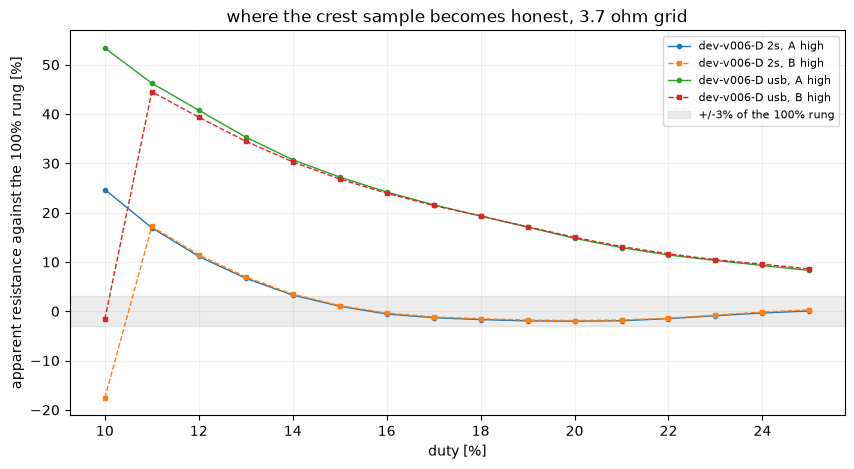

In [9]:
TOL_PCT = 3.0


def ladder_rungs(k, d):
    b, kv = d.board, K_VDD[k]
    out = []
    for cap in d.captures("ladder"):
        for rec in d.recordings("ladder", cap):
            df = frame(rec)
            base = df[df["seg"] == 0]
            base = base.iloc[len(base) // 2:]
            bias = base["current_raw"].median()
            for seg, g in df[df["seg"] > 0].groupby("seg"):
                g = settled(g)
                if len(g) < 20:
                    continue
                a, bb = g["vmotor_a"].mean(), g["vmotor_b"].mean()
                if ROUTE[k] == "ab":
                    v = abs(b.diff_v(a, bb)) * kv
                elif a > bb:
                    v = b.term_v(a, bb) * kv
                else:
                    continue
                i = abs(b.amps(g["current_raw"].mean(), bias)) * kv
                out.append({"dataset": k, "capture": cap, "seg": seg,
                            "duty_pct": abs(round(g["cmd_duty_q15"].iloc[0] * 100.0 / Q15)),
                            "dir": "A high" if a > bb else "B high",
                            "current_A": i, "V": v, "R_app_ohm": v / i,
                            "rail_V": b.vsys_v(g["vbus_raw"].mean()) * kv})
    return out


RUNGS = pd.DataFrame(sum((ladder_rungs(k, d) for k, d in GDS.items()), []))
LAD = (RUNGS.groupby(["dataset", "dir", "duty_pct"])
       .agg(rungs=("R_app_ohm", "size"), current_A=("current_A", "mean"), V=("V", "mean"),
            R_app_ohm=("R_app_ohm", "mean"), rail_V=("rail_V", "mean")).reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
for (k, direction), s in LAD.groupby(["dataset", "dir"]):
    s = s.set_index("duty_pct").sort_index()
    if 100 not in s.index:
        continue
    ref = s.loc[100, "R_app_ohm"]
    s = s[s.index < 100]
    ax.plot(s.index, (s["R_app_ohm"] / ref - 1) * 100, "-o" if direction == "A high" else "--s",
            ms=3, lw=1, label=f"{LABEL[k]}, {direction}")
    floor = None
    for duty in sorted(s.index, reverse=True):
        if abs(s.loc[duty, "R_app_ohm"] / ref - 1) * 100 > TOL_PCT:
            break
        floor = duty
    note = ""
    if floor is None:
        # No rung inside the band: a line over the top five rungs says where it would cross.
        # That crossing sits outside the measured range, so it is an extrapolation.
        top = s[s.index >= s.index.max() - 5]
        kk = np.polyfit(top.index.astype(float), top["R_app_ohm"], 1)
        note = f"no rung inside {TOL_PCT:.0f}%, a line over the top rungs crosses at {(ref * (1 + TOL_PCT / 100) - kk[1]) / kk[0]:.0f}% (extrapolated)"
    else:
        note = f"honest to {TOL_PCT:.0f}% from {floor:.0f}% duty"
    CARD[k][f"crest honest from, {direction} [% duty]"] = floor if floor is not None else np.nan
    CARD[k][f"100% rung R_app, {direction} [ohm]"] = ref
    print(f"{LABEL[k]:<20} {direction:<7} 100% rung {ref:.4f} ohm, lowest rung {s.index.min()}% "
          f"{(s['R_app_ohm'].iloc[0] / ref - 1) * 100:+.1f}% | {note}")
ax.axhspan(-TOL_PCT, TOL_PCT, color="grey", alpha=0.15, label=f"+/-{TOL_PCT:.0f}% of the 100% rung")
ax.set_xlabel("duty [%]")
ax.set_ylabel("apparent resistance against the 100% rung [%]")
ax.set_title("where the crest sample becomes honest, 3.7 ohm grid")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at:** each rung's apparent resistance as a percentage of the same
board's 100% rung, per direction. The grey band is the 3% tolerance. A board whose crest
sample is honest at low duty stays inside the band further to the left.

## 6. The shunt inside one PWM period

The bursts free-run the ADC on the shunt alone at 26 ADC clocks a sample, 1.0833 us at
24 MHz, which is about 46 samples a period. Folding a burst on the period shows the current
inside the ON window, which the crest sample can only ever see one slice of. The longest ON
window in the set shows the whole approach, and the slot where it stays inside 1% of its
plateau says from which duty a crest sample centred in the window clears it.

dev-v006-D 2s        40% burst: plateau 1.710 A, inside 1% from slot 4 (4.3 us), a centred crest clears it from 17% duty; first slots 1.031 1.445 1.692 1.749 1.726 1.704
dev-v006-D usb       40% burst: plateau 1.122 A, inside 1% from slot 8 (8.7 us), a centred crest clears it from 35% duty; first slots 0.558 0.755 0.879 0.966 1.027 1.065


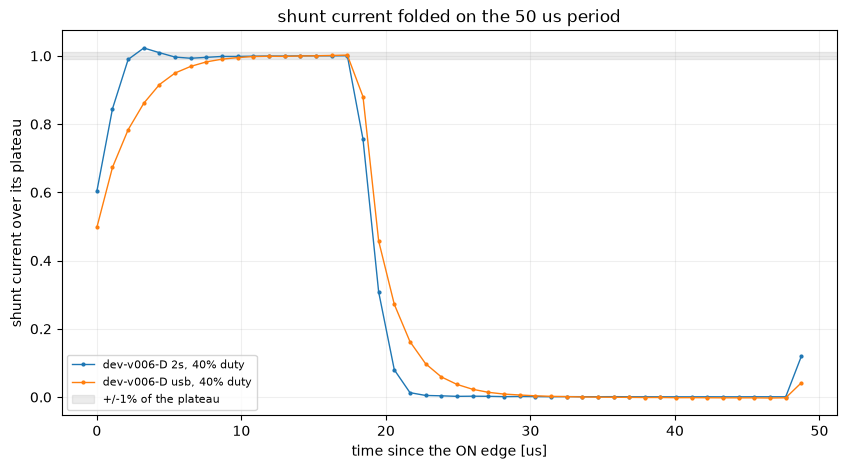

In [10]:
BURST_TS_US = 26 / 24.0
SETTLE_TOL = 0.01


def fold_burst(path, b, kv):
    # Average one burst over its PWM periods, aligned on the ON edge (median phase of the
    # biggest positive jumps, so one noisy period cannot shift the fold).
    raw = pd.read_csv(path)
    meta = raw.iloc[0]
    counts = raw["raw"].to_numpy(float)
    if int(meta["frame_len"]) != 1:
        counts = counts[::int(meta["frame_len"])]
    amps = b.amps(counts, float(meta["bias"])) * kv
    slots_f = 1e6 / b.tick_hz / BURST_TS_US
    edges = np.where(np.diff(amps) > 0.25 * (amps.max() - amps.min()))[0]
    phase = np.median(edges % slots_f)
    slots, nper = int(round(slots_f)), int(len(amps) // slots_f) - 1
    prof = np.full((nper, slots), np.nan)
    for p in range(nper):
        s = int(round(phase + p * slots_f)) + 1
        chunk = amps[s:s + slots]
        prof[p, :len(chunk)] = chunk
    return np.nanmean(prof, axis=0), slots_f


FOLDS = {}
for k, d in GDS.items():
    files = sorted((d.path / "burst").glob("c0-d*-*.csv"))
    if not files:
        print(f"{LABEL[k]}: no shunt bursts")
        continue
    duties = sorted({int(f.stem.split("-")[1][1:]) for f in files})
    for duty in duties:
        reps = [fold_burst(f, d.board, K_VDD[k]) for f in files if f.stem.split("-")[1] == f"d{duty}"]
        FOLDS[(k, duty)] = (np.nanmean([r[0] for r in reps], axis=0), reps[0][1])
    duty = duties[-1]
    prof, slots_f = FOLDS[(k, duty)]
    on = int(round(duty / 100 * slots_f))
    plateau = np.nanmean(prof[on - 6:on - 2])
    inside = np.abs(prof[:on - 2] - plateau) <= SETTLE_TOL * plateau
    first = len(inside)
    while first > 0 and inside[first - 1]:
        first -= 1
    c = CARD[k]
    c["burst plateau [A]"] = plateau
    c["shunt settled to 1% [us after the ON edge]"] = first * BURST_TS_US
    c["centred crest clears it from [% duty]"] = first * 2 / slots_f * 100
    print(f"{LABEL[k]:<20} {duty}% burst: plateau {plateau:.3f} A, inside 1% from slot {first} "
          f"({first * BURST_TS_US:.1f} us), a centred crest clears it from {first * 2 / slots_f * 100:.0f}% duty; "
          f"first slots " + " ".join(f"{x:.3f}" for x in prof[:6]))

fig, ax = plt.subplots(figsize=(10, 5))
for k in GDS:
    keys = [kd for kd in FOLDS if kd[0] == k]
    if not keys:
        continue
    kd = max(keys, key=lambda x: x[1])
    prof, _ = FOLDS[kd]
    ax.plot(np.arange(len(prof)) * BURST_TS_US, prof / CARD[k]["burst plateau [A]"], "-o", ms=2, lw=1,
            label=f"{LABEL[k]}, {kd[1]}% duty")
ax.axhspan(1 - SETTLE_TOL, 1 + SETTLE_TOL, color="grey", alpha=0.15, label="+/-1% of the plateau")
ax.set_xlabel("time since the ON edge [us]")
ax.set_ylabel("shunt current over its plateau")
ax.set_title("shunt current folded on the 50 us period")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at:** the shunt current inside one PWM period, as a fraction of its own
plateau, for the longest ON window each dataset has. The sooner a curve enters the grey band
and stays, the lower the duty at which a single crest sample reads the real current.

## 7. Board against board

One row per figure, one column per dataset, plus the figure board D's registry entry carries
and where it came from. A blank cell is a measurement that dataset does not have.

In [11]:
REG = oscnb.boards.BOARDS["dev-v006-D"].measured
REGISTRY = {
    "VDD by meter [V]": "vdd_measured",
    "VB rest, tap A [counts]": "vb_bias_measured",
    "rest current sd [counts]": "opa_noise_floor_measured",
    "terminal vs meter, worst vs midpoint [%]": "terminal_chain_measured",
    "current vs meter, mean [%]": "current_chain_scale_measured",
    "crest honest from, A high [% duty]": "crest_floor_measured",
}
table = pd.DataFrame({LABEL[k]: CARD[k] for k in GDS})
table["board D registry"] = [
    (f"{REG[REGISTRY[q]].value:g} [{REG[REGISTRY[q]].lo:g}, {REG[REGISTRY[q]].hi:g}] "
     f"({REG[REGISTRY[q]].source})") if q in REGISTRY else "" for q in table.index]
pd.set_option("display.max_colwidth", 70)
table.map(lambda v: round(v, 3) if isinstance(v, float) else v)

,dev-v006-D 2s,dev-v006-D usb,board D registry
terminal route,taps A and B,taps A and B,
VDD by meter [V],3.28,3.28,"3.28 [3.27, 3.29] (nb00 sec 10.1, DMM at the 3V3 test point)"
"VB rest, tap A [counts]",779.168,779.059,"781 [775, 783] (Hi-Z rest baseline, 2S grid + stepcoast)"
"VB rest, tap B [counts]",783.146,783.023,
VB nominal [counts],779.401,779.401,
"VB rest, tap A [mV]",623.943,623.856,
VB by meter [mV],NaN,NaN,
rest current sd [counts],1.697,1.902,"2.2 [2, 2.4] (bringup isns-diff run29)"
rest current sd [mA],1.51,1.692,
rest tap A sd [mV at the terminal],2.009,1.802,


Board D's column agrees with notebook 00 section 10 everywhere it overlaps. VDD is 3.28 V. The
terminal chain is within 0.44% of the meter's band on all five metered laps, 0.67% from the
worst midpoint, and three of the five sit inside the band. The crest current is honest from
15% duty in both directions on 2S and from no rung of the USB ladder. The 40% burst settles
inside 1% at slot 4 on 2S, 4.3 us, and slot 8 on USB. The current chain lands at +1.13% against the registry's +1.2%, and that difference is
the lead drop in section 4.2 and nothing else.

Two registry rows are not reruns of anything here. The bias figure, 781 counts, came from the
servo campaigns' torque-off baselines, where taps A and B read 778 and 782. On the grid
baseline they read 779 and 783, the same four-count split. The 2.2-count amplifier floor came
from a bringup bench run, and the grid baseline's 1.7 counts is the whole chain at rest with
the bridge off.

## 8. What is open

- **The rev-2A column.** Nothing here is measured on 2A yet. To beat board D the 2A session
  has to show tap A inside the meter's band on MOT_A to ground, the current inside 1% with a
  series ammeter or with the Rs1 route, a crest current honest well under 15% on 2S (the 2A
  target is 8%), and a burst that settles in fewer slots than board D's four.
- **The tap-A route's blind spot.** On a board whose tap B reads the bias node, every
  forward-lap terminal number includes the low side, about 0.27 ohm on board D. The reverse laps
  measure the A-side copy of that path, and the B side is assumed to match it. Board D's own
  two sides matched to 1.4% (0.448 V against 0.454 V at 1.69 A), but board D's island was the
  thing rev 2A redesigned, so that is an assumption on 2A until Rv3 is fixed and the
  difference is read with both taps. The experiment that settles it is the same lap pair again
  after the repair, forward and reverse, with the meter on MOT_A and MOT_B to ground.
- **The live-bias trick.** Converting tap A against tap B as the bias assumes tap B carries no
  current of its own, which holds only while Rv3 is open. A tap B that drifts with drive by
  more than the bias node should move (tens of millivolts at 100%) says it does not hold. The
  check is the meter on VB at Cb1 during a lap, against tap B in the same lap, which section
  4.1 grades whenever the meter log has that row.
- **Board D's current direction effect.** The terminal difference reads 1.3% lower in reverse
  at the same shunt current, on the chip and on the meter alike (notebook 00 sec 10.4). Rev 2A
  enters the shunt symmetrically from both low FETs, so the forward and reverse 100% rungs on
  2A should agree in apparent resistance within the low-side difference.

Next is the 2A grid session itself. When its folder lands, rerun this notebook and the 2A
column fills in, then the registry entry for `dev-v006-2A` gets its `measured` values from
here.